In [501]:
# Import all the necessary libraries.
import numpy as np
import matplotlib.pyplot as plt

# Import the linear regression module from the scikit learn library.
from sklearn.linear_model import LinearRegression

In [502]:
# Resetando gerador de sequências pseudo-aleatórias de forma que os resultados apresentados sejam sempre os mesmos.
seed = 1234
np.random.seed(seed)

In [503]:
M = 1000

#atributos
x = np.random.uniform(-5,5,M)

#ruído
w = np.random.normal(0,np.sqrt(10),M)  #Distribuição aleatória gaussiana -> atributos: (media,np.sqrt(variancia),num de elementos)

#target function
y = 3+1.5*x+2.3*x**2
# observable function

y_noisy = y + w

print(y_noisy.shape)


(1000,)


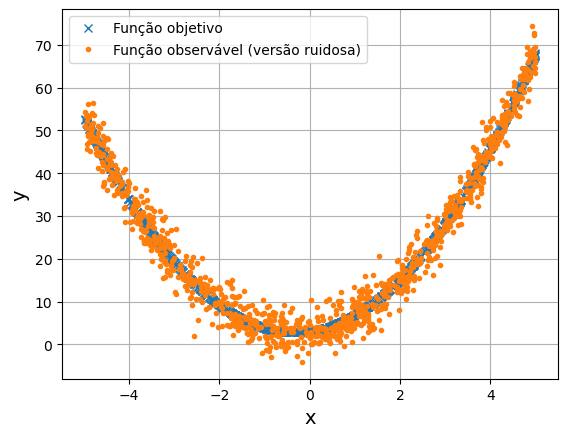

In [504]:
# Comparando a função observável com a objetivo.
fig = plt.figure()
plt.plot(x, y, 'x' , label='Função objetivo')
plt.plot(x, y_noisy, '.', label='Função observável (versão ruidosa)')
plt.xlabel('x', fontsize=14)
plt.ylabel('y', fontsize=14)
plt.legend()
plt.grid()
plt.show()

In [505]:
# np.c_ concatenates vectors.
X = np.c_[np.ones((M, 1)), x, x**2] # Precisa colocar todas as ordens da equação, o exemplo tem x e x²

# Solve by applying the least-Squares method.
# We use the inv() function from NumPy’s Linear Algebra module (np.linalg) to compute the inverse of a matrix.
# We use dot() method for matrix multiplication.
a_numpy = np.linalg.inv(X.T.dot(X)).dot(X.T).dot(y_noisy)

# Print best solution.
print('a0: %1.4f' % (a_numpy[0]))
print('a1: %1.4f' % (a_numpy[1]))
print('a2: %1.4f' % (a_numpy[2]))


a0: 2.9844
a1: 1.4885
a2: 2.3073


In [506]:
# Performing predictions with the hypothesis function.
yhat_numpy = X.dot(a_numpy)

# Calculating the Mean Squared Error (MSE).
Je_optimum = (1.0/M)*np.sum(np.power((y_noisy - yhat_numpy), 2))

# Print the MSE.
print('MSE: %1.6f' % Je_optimum)


# Se o erro estiver próximo da variância então está correto.

MSE: 9.937470


#Encontrando a solução ótima com a equação normal implementada pela biblioteca Scikit-learn

In [507]:
# Usando o poly, pois é um polinômio, tem x e x².
X_poly = np.c_[x,x**2]

# Instantiate the LinearRegression class.
reg = LinearRegression()

# Train the model.
reg.fit(X_poly, y_noisy.ravel())

print('a0: %1.4f' % (reg.intercept_)) # Intercept = a0
print('a1: %1.4f' % (reg.coef_[0]))   # Coef. de x
print('a2: %1.4f' % (reg.coef_[1]))   # Coef. de x²

# Performing predictions with the hypothesis function.
yhat_sklearn = reg.predict(X_poly)

# Calculating the Mean Squared Error (MSE).
Je_sklearn = (1.0/M)*np.sum(np.power((y_noisy - yhat_sklearn), 2))

# Print the MSE.
print('MSE: %1.6f' % Je_sklearn)

a0: 2.9844
a1: 1.4885
a2: 2.3073
MSE: 9.937470


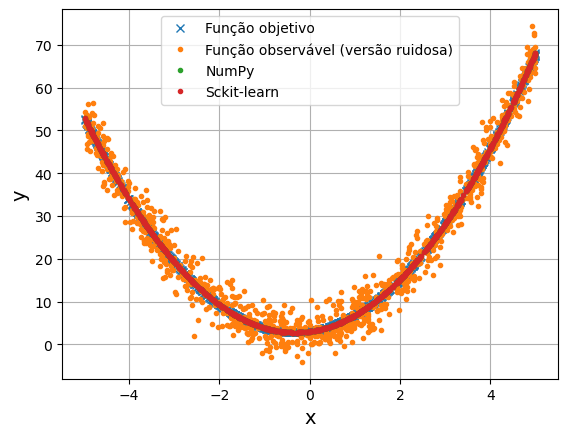

In [508]:
# Plot pair example/label.
fig = plt.figure()
plt.plot(x, y, 'x', label='Função objetivo', linewidth=7)
plt.plot(x, y_noisy, '.', label='Função observável (versão ruidosa)')
plt.plot(x, yhat_numpy, '.', label='NumPy', linewidth=4)
plt.plot(x, yhat_sklearn, '.', label='Sckit-learn')
plt.xlabel('x', fontsize=14)
plt.ylabel('y', fontsize=14)
plt.legend()
plt.grid()
plt.show()

#BATELADA

In [509]:
def batchGradientDescent(X, y, alpha, maxNumEpoch):
    """Batch gradient descent solution."""
    
    # Get the number of training examples.
    N = len(y)

    # Ensuring that y is a column vector
    y = y.reshape(N,1)

    # Initialize error history with zeros.
    Jgd = np.zeros(maxNumEpoch+1)

    # Initialization of parameters (weights are generally random initialized).
    a = np.array([-10.0, -10.0, -10.0]).reshape(3, 1)

    # Create matrix for parameter history.
    a_hist = np.zeros((3, maxNumEpoch+1))
    # Initialize history matrix.
    a_hist[:, 0] = a.reshape(3,)

    # Hypothesis function.
    yhat = X.dot(a)
    # Initial MSE.
    Jgd[0] = (1.0/N)*sum(np.power((y[:,0] - yhat[:,0]), 2))

    # Initialize gradient history matrix with zeros.
    grad_hist = np.zeros((3, maxNumEpoch))

    # Batch gradient-descent loop.
    error = 1 # Error between consecutive epochs.
    epoch = 0 # Epoch counter.
    while(error > 1e-5 and epoch < maxNumEpoch-1):

        # Calculate the gradient vector.
        yhat = X.dot(a)
        gradients = -X.T.dot(y - yhat)

        # Update the weights.
        a = a - alpha * gradients

        # Store new weights into the matrix.
        a_hist[:, epoch+1] = a.reshape(3,)

        # Calculate and store the MSE for the new weights.
        yhat = X.dot(a)
        Jgd[epoch+1] = (1.0/N)*sum(np.power((y[:,0] - yhat[:,0]), 2))

        # Calculate the error between consecutive epochs.
        error = np.abs(Jgd[epoch]-Jgd[epoch+1])

        # Update the gradient history.
        grad_hist[:, epoch] = gradients.reshape(3,)

        # Increment the epoch.
        epoch += 1

    return a, a_hist, Jgd, grad_hist, epoch



In [510]:
maxNumEpoch = 1000
alpha = 0.00001

a, a_hist, Jgd, grad_hist, epoch = batchGradientDescent(X, y_noisy, alpha, maxNumEpoch)   

y_pred = X.dot(a)
Je_GD_batch = (1.0/M)*np.sum(np.power((y_noisy - y_pred.ravel()), 2))

print(f'GD-batch solution a0: {a[0, 0]}')
print(f'GD-batch solution a1: {a[1, 0]}')
print(f'GD-batch solution a2: {a[2, 0]}')

print("")
print('MSE: %1.6f' % Je_GD_batch)


GD-batch solution a0: 2.8292100840372902
GD-batch solution a1: 1.4889432103065539
GD-batch solution a2: 2.317388547829515

MSE: 9.947988


Gradiente Descendente (a0, a1, a2): [2.96381558 1.50011267 2.30235036]
Erro quadrático médio (gradiente): 9.943995793346573


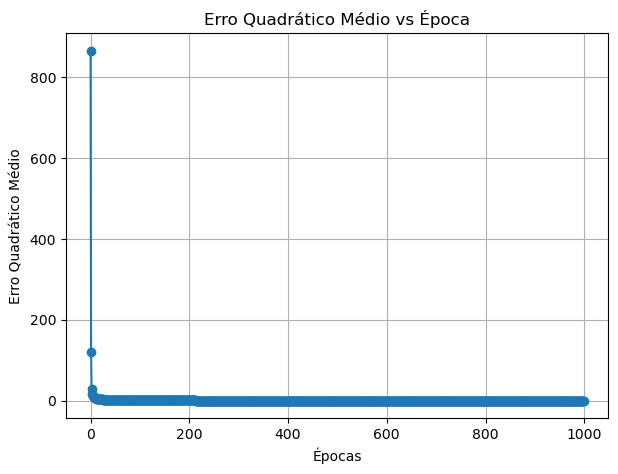

In [511]:
a_vet = np.zeros((3, 1)) # Vetor de pesos inicializados como 0, shape (3,1) pois temos a0,a1,e a2
alpha = 0.01  # passo de aprendizagem
n_epochs = 1000
errors = [] # lista para guardar o erro quadrático médio ao longo das iterações.


# modelo atualizado repetidamente por 200 épocas
for epoch in range(n_epochs):
    # Matriz colinas [1,x,x²]
    # @ produto matricial entre x e os pesos a_vet
    # y_pred: vetor com as predições.
    y_pred = X @ a_vet

    # garante que y esteja na forma de vetor coluna.
    y = y.reshape(-1, 1)

    # diferença entre a predição e o valor real.
    error = y_pred - y

    # GRADIENTE
    grad = (1/M) * (X.T @ error)

    # Atualiza os coeficientes na direção contrária ao gradiente para minimizar o erro.
    a_vet -= alpha * grad

    # Erro quadrático médio
    mse = np.mean(error**2)
    errors.append(mse)

ypred = X.dot(a_vet)

Je_GD_batch = (1.0/M)*np.sum(np.power((y_noisy - y_pred.ravel()), 2))

print("Gradiente Descendente (a0, a1, a2):", a_vet.ravel())
print("Erro quadrático médio (gradiente):", Je_GD_batch)

### --- Plot do erro por iteração ---
plt.figure(figsize=(7, 5))
plt.plot(range(n_epochs), errors, marker='o')
plt.title("Erro Quadrático Médio vs Época")
plt.xlabel("Épocas")
plt.ylabel("Erro Quadrático Médio")
plt.grid(True)
plt.show()